In [1]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
SUBJECT = "P1"
SESSION = 1
TRIAL   = 2          # trial index within the session (0-based)
GF_THRESH_FRAC = 0.8
GF_PERSIST     = 5   # consecutive samples required for valid crossing

EEG_CHANNELS = ["Cz", "Fz", "C3", "C4", "F3", "F4"]  # subset to plot

HS_PATH = f"../data/WAY-EEG-GAL/{SUBJECT}/HS_{SUBJECT}_S{SESSION}.mat"
WS_PATH = f"../data/WAY-EEG-GAL/{SUBJECT}/WS_{SUBJECT}_S{SESSION}.mat"
AL_PATH = f"../data/WAY-EEG-GAL/{SUBJECT}/{SUBJECT}_AllLifts.mat"

# ── Load data ─────────────────────────────────────────────────────────────────
hs     = sio.loadmat(HS_PATH, simplify_cells=True)["hs"]
eeg    = hs["eeg"]
X      = np.array(eeg["sig"], dtype=np.float32)   # (N, 32)
fs     = int(eeg["samplingrate"])
ch_names = list(eeg["names"])
t_eeg  = np.arange(len(X)) / fs

ws     = sio.loadmat(WS_PATH, simplify_cells=True)["ws"]
wins   = ws["win"]
kin_names = list(ws["names"]["kin"])
GF_IDX = kin_names.index("GF")

al_raw = sio.loadmat(AL_PATH, simplify_cells=True)["P"]
al     = dict(zip(al_raw["ColNames"], al_raw["AllLifts"].T))

print(f"EEG: {X.shape}  fs={fs} Hz  duration={len(X)/fs:.1f}s")
print(f"Sessions in WS: {len(wins)} trials")
# Filter AllLifts to current session only
run_mask = al["Run"].astype(int) == SESSION
al_s = {k: v[run_mask] for k, v in al.items()
        if hasattr(v, '__len__') and len(v) == len(al["Run"])}

print(f"EEG: {X.shape}  fs={fs} Hz  duration={len(X)/fs:.1f}s")
print(f"WS trials in session: {len(wins)}")
# Sort al_s by StartTime to match chronological order of wins
sort_idx = np.argsort(al_s["StartTime"])
al_s = {k: v[sort_idx] for k, v in al_s.items()}

print(f"AllLifts rows for session {SESSION}: {run_mask.sum()}")
print(f"EEG channels: {ch_names}")


EEG: (119496, 32)  fs=500 Hz  duration=239.0s
Sessions in WS: 34 trials
EEG: (119496, 32)  fs=500 Hz  duration=239.0s
WS trials in session: 34
AllLifts rows for session 1: 34
EEG channels: ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP9', 'CP5', 'CP1', 'CP2', 'CP6', 'TP10', 'P7', 'P3', 'Pz', 'P4', 'P8', 'PO9', 'O1', 'Oz', 'O2', 'PO10']


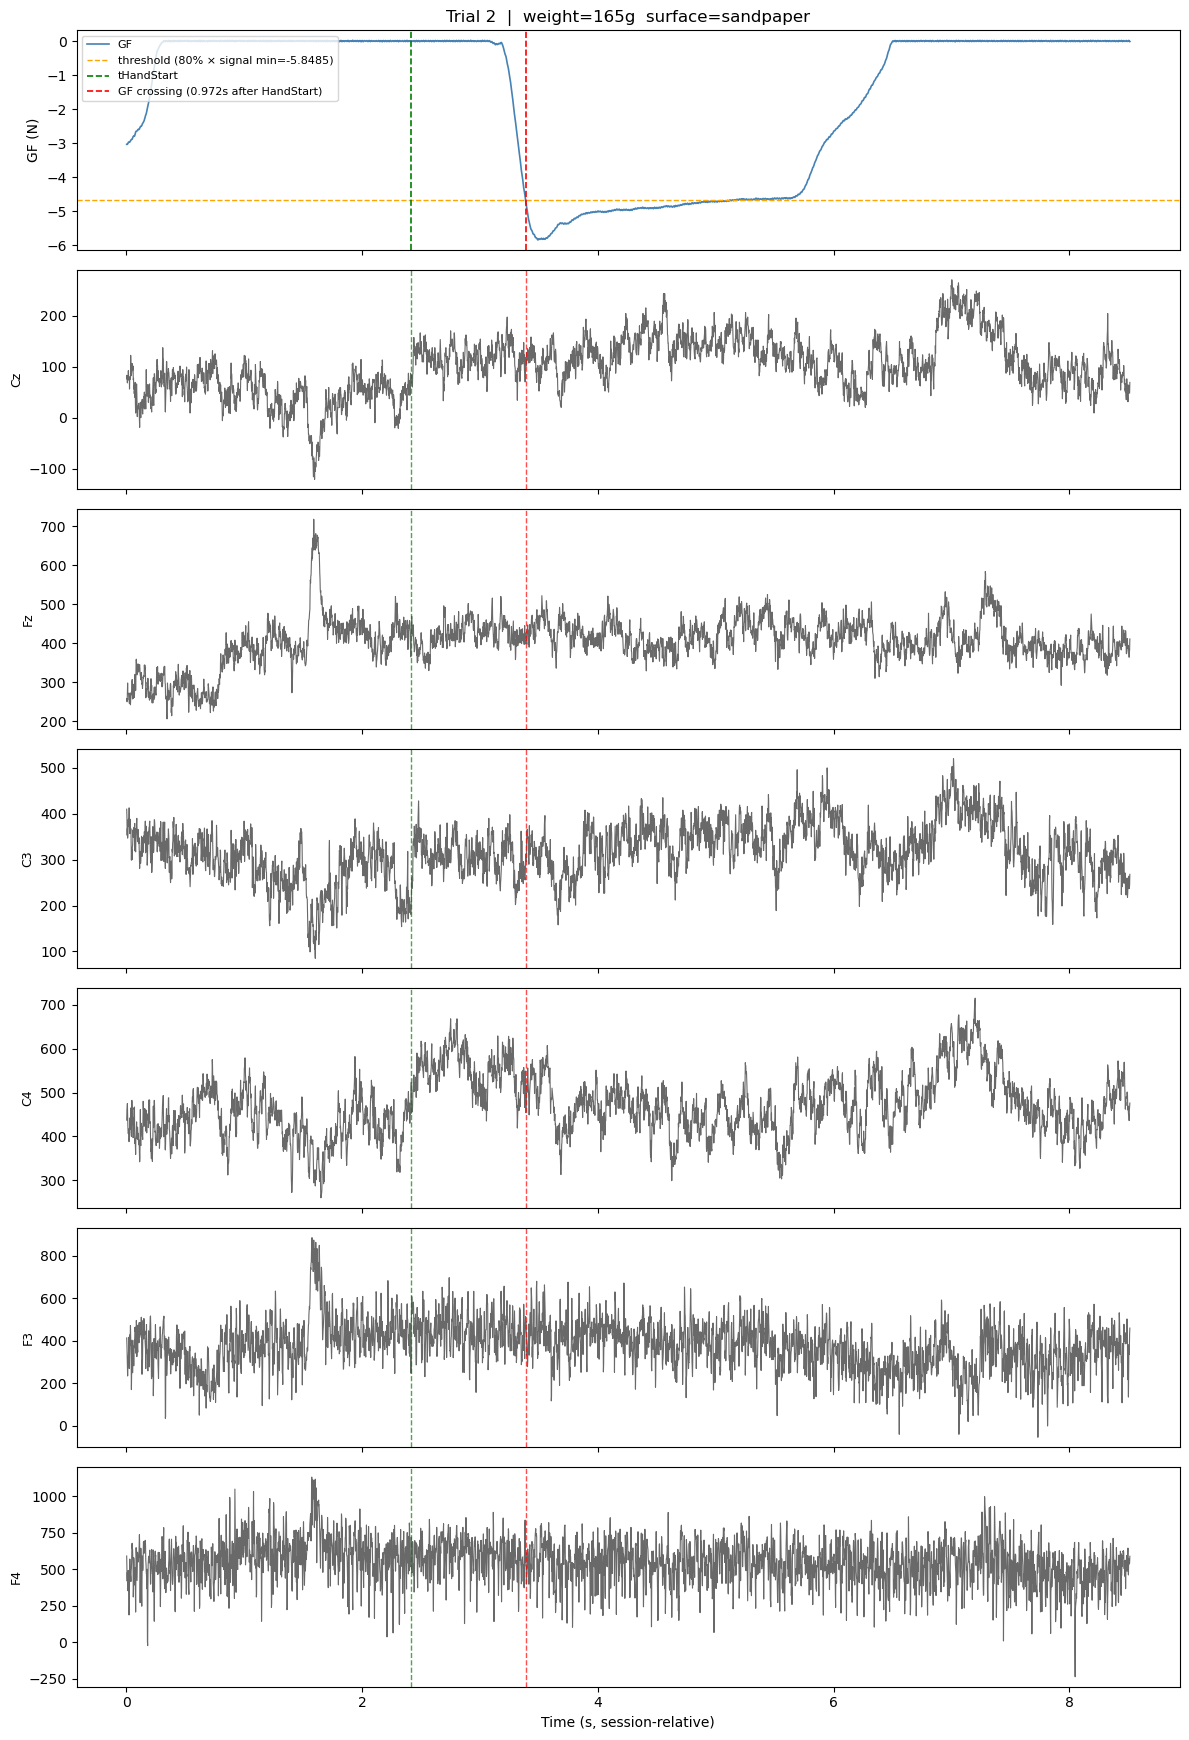

GF min: -5.8485  threshold: -4.6788
tHandStart : 2.414s
GF crossing: 3.386s  (lag=0.972s)


In [2]:
# ── Plot GF + EEG for one trial ───────────────────────────────────────────────
w   = wins[TRIAL]
gf  = w["kin"][:, GF_IDX]
t_w = w["eeg_t"]                    # absolute timestamps (session-relative)
eeg_w = w["eeg"]                    # (N_trial, 32) — trial EEG window

t_start = w["trial_start_time"]
t_end   = w["trial_end_time"]

# GF threshold & crossing
gf_min    = gf.min()          # GF goes negative during grip
threshold = GF_THRESH_FRAC * gf_min  # negative threshold
t_hand    = al_s["tHandStart"][TRIAL]  # trial-relative (eeg_t starts at 0)

t_cross = None
candidates = np.where(gf < threshold)[0]  # downward crossing
for idx in candidates:
    if idx + GF_PERSIST <= len(gf) and np.all(gf[idx:idx + GF_PERSIST] < threshold):
        if t_w[idx] >= t_hand:  # both trial-relative
            t_cross = float(t_w[idx])
            break

# ── Figure ────────────────────────────────────────────────────────────────────
n_eeg = len(EEG_CHANNELS)
fig, axes = plt.subplots(n_eeg + 1, 1, figsize=(12, 2.5 * (n_eeg + 1)), sharex=True)

# GF panel
ax = axes[0]
ax.plot(t_w, gf, color="steelblue", lw=1.2, label="GF")
ax.axhline(threshold, color="orange", ls="--", lw=1,
           label=f"threshold ({GF_THRESH_FRAC:.0%} × signal min={gf_min:.4f})")
ax.axvline(t_hand,  color="green",  ls="--", lw=1.2, label=f"tHandStart")
if t_cross:
    ax.axvline(t_cross, color="red", ls="--", lw=1.2,
               label=f"GF crossing ({t_cross - t_hand:.3f}s after HandStart)")
ax.set_ylabel("GF (N)")
ax.set_title(f"Trial {TRIAL}  |  weight={w['weight_id']}  surface={w['surf_id']}")
ax.legend(fontsize=8, loc="upper left")

# EEG panels
for i, ch in enumerate(EEG_CHANNELS):
    ax = axes[i + 1]
    if ch in ch_names:
        sig = eeg_w[:, ch_names.index(ch)]
        ax.plot(t_w, sig, color="dimgray", lw=0.8)
    else:
        ax.text(0.5, 0.5, f"{ch} not in montage", transform=ax.transAxes, ha="center")
    ax.axvline(t_hand, color="green", ls="--", lw=1, alpha=0.7)
    if t_cross:
        ax.axvline(t_cross, color="red", ls="--", lw=1, alpha=0.7)
    ax.set_ylabel(ch, fontsize=9)

axes[-1].set_xlabel("Time (s, session-relative)")
fig.tight_layout()
plt.show()

print(f"GF min: {gf_min:.4f}  threshold: {threshold:.4f}")
print(f"tHandStart : {t_hand:.3f}s")
print(f"GF crossing: {t_cross:.3f}s  (lag={t_cross - t_hand:.3f}s)" if t_cross else "No valid GF crossing found")


In [38]:
from tqdm import tqdm
GFS = []
LATENCY = []

SUBJECT = "P1"
for SESSION in tqdm(range(1, 10)):
    GF_THRESH_FRAC = 0.8
    GF_PERSIST     = 5   # consecutive samples required for valid crossing

    EEG_CHANNELS = ["Cz", "Fz", "C3", "C4", "F3", "F4"]  # subset to plot

    HS_PATH = f"../data/WAY-EEG-GAL/{SUBJECT}/HS_{SUBJECT}_S{SESSION}.mat"
    WS_PATH = f"../data/WAY-EEG-GAL/{SUBJECT}/WS_{SUBJECT}_S{SESSION}.mat"
    AL_PATH = f"../data/WAY-EEG-GAL/{SUBJECT}/{SUBJECT}_AllLifts.mat"
# ── Load data ─────────────────────────────────────────────────────────────────
    hs     = sio.loadmat(HS_PATH, simplify_cells=True)["hs"]
    eeg    = hs["eeg"]
    X      = np.array(eeg["sig"], dtype=np.float32)   # (N, 32)
    fs     = int(eeg["samplingrate"])
    ch_names = list(eeg["names"])
    t_eeg  = np.arange(len(X)) / fs

    ws     = sio.loadmat(WS_PATH, simplify_cells=True)["ws"]
    wins   = ws["win"]
    kin_names = list(ws["names"]["kin"])
    GF_IDX = kin_names.index("GF")

    al_raw = sio.loadmat(AL_PATH, simplify_cells=True)["P"]
    al     = dict(zip(al_raw["ColNames"], al_raw["AllLifts"].T))

    print(f"EEG: {X.shape}  fs={fs} Hz  duration={len(X)/fs:.1f}s")
    print(f"Sessions in WS: {len(wins)} trials")
    # Filter AllLifts to current session only
    run_mask = al["Run"].astype(int) == SESSION
    al_s = {k: v[run_mask] for k, v in al.items()
            if hasattr(v, '__len__') and len(v) == len(al["Run"])}

    print(f"EEG: {X.shape}  fs={fs} Hz  duration={len(X)/fs:.1f}s")
    print(f"WS trials in session: {len(wins)}")
    # Sort al_s by StartTime to match chronological order of wins
    sort_idx = np.argsort(al_s["StartTime"])
    al_s = {k: v[sort_idx] for k, v in al_s.items()}

    for TRIAL in range(len(wins)):
        w   = wins[TRIAL]
        gf  = w["kin"][:, GF_IDX]
        t_w = w["eeg_t"]                    # absolute timestamps (session-relative)
        eeg_w = w["eeg"]                    # (N_trial, 32) — trial EEG window

        t_start = w["trial_start_time"]
        t_end   = w["trial_end_time"]

        # GF threshold & crossing
        gf_min    = gf.min()          # GF goes negative during grip
        threshold = GF_THRESH_FRAC * gf_min  # negative threshold
        t_hand    = al_s["tHandStart"][TRIAL]  # trial-relative (eeg_t starts at 0)

        LATENCY.append(al_s["tHandStart"][TRIAL] - al_s["LEDOn"][TRIAL])

        GFS.append( gf < threshold )

 11%|█         | 1/9 [00:00<00:04,  2.00it/s]

EEG: (119496, 32)  fs=500 Hz  duration=239.0s
Sessions in WS: 34 trials
EEG: (119496, 32)  fs=500 Hz  duration=239.0s
WS trials in session: 34


 22%|██▏       | 2/9 [00:01<00:04,  1.60it/s]

EEG: (271954, 32)  fs=500 Hz  duration=543.9s
Sessions in WS: 34 trials
EEG: (271954, 32)  fs=500 Hz  duration=543.9s
WS trials in session: 34


 33%|███▎      | 3/9 [00:01<00:03,  1.67it/s]

...

EEG: (119561, 32)  fs=500 Hz  duration=239.1s
Sessions in WS: 34 trials
EEG: (119561, 32)  fs=500 Hz  duration=239.1s
WS trials in session: 34


 89%|████████▉ | 8/9 [00:04<00:00,  1.86it/s]

EEG: (117333, 32)  fs=500 Hz  duration=234.7s
Sessions in WS: 34 trials
EEG: (117333, 32)  fs=500 Hz  duration=234.7s
WS trials in session: 34


100%|██████████| 9/9 [00:04<00:00,  1.83it/s]

EEG: (115953, 32)  fs=500 Hz  duration=231.9s
Sessions in WS: 34 trials
EEG: (115953, 32)  fs=500 Hz  duration=231.9s
WS trials in session: 34


In [5]:
np.diff(gf < threshold) 

array([False, False, False, ..., False, False, False])

In [6]:
True-False

1

ValueError: x and y must have same first dimension, but have shapes (4269,) and (4268,)

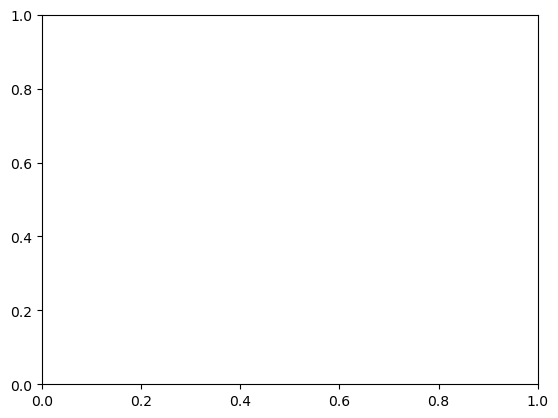

In [7]:
plt.plot(np.arange(t_start, t_end + 1/500, 1/500), eeg_w[:, 0])